In [1]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

# -------------------------------
# Plot configuration
# -------------------------------
def configure_plots(width=10, height=4, font_size=12):
    plt.rcParams.update({
        "figure.figsize": (width, height),
        "font.size": font_size
    })

configure_plots()

In [2]:

# -------------------------------
# Utility functions
# -------------------------------
def initialize_seed(seed):
    np.random.seed(seed)

def select_action_epsilon(Q_table, state, eps, action_space):
    if np.random.random() < eps:
        return np.random.choice(action_space.n)
    return int(np.argmax(Q_table[state]))

In [3]:
# -------------------------------
# Q-Learning
# -------------------------------
def run_q_learning(
    episodes=500,
    lr=0.5,
    discount=0.99,
    eps_init=0.1,
    eps_floor=0.01,
    eps_decay_rate=1.0,
    random_seed=0,
):
    initialize_seed(random_seed)

    env = gym.make("CliffWalking-v1")
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    Q = np.zeros((n_states, n_actions))
    rewards = []

    eps = eps_init

    for ep in range(episodes):
        state, _ = env.reset(seed=random_seed + ep)
        done = False
        total_reward = 0

        while not done:
            action = select_action_epsilon(Q, state, eps, env.action_space)

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward

            next_val = 0 if done else np.max(Q[next_state])
            target = reward + discount * next_val

            Q[state, action] += lr * (target - Q[state, action])
            state = next_state

        rewards.append(total_reward)
        eps = max(eps_floor, eps * eps_decay_rate)

    env.close()
    return Q, np.array(rewards)

In [4]:
# -------------------------------
# Multi-seed experiment
# -------------------------------
def evaluate_across_seeds(
    method="sarsa",
    seeds=30,
    episodes=500,
    lr=0.5,
    discount=0.99,
    eps_start=0.1,
    eps_min=0.01,
    eps_decay=1.0,
):
    all_runs = []
    last_Q = None

    method = method.lower()
    if method == "sarsa":
        trainer = run_sarsa
    elif method in ["q_learning", "q-learning", "qlearning"]:
        trainer = run_q_learning
    else:
        raise ValueError("Invalid method")

    for s in range(seeds):
        Q, returns = trainer(
            episodes=episodes,
            lr=lr,
            discount=discount,
            eps_init=eps_start,
            eps_floor=eps_min,
            eps_decay_rate=eps_decay,
            random_seed=s,
        )

        all_runs.append(returns)
        last_Q = Q

    return np.vstack(all_runs), last_Q

In [ ]:
# -------------------------------
# SARSA 
# -------------------------------
def run_sarsa(
    episodes=500,
    lr=0.5,
    discount=0.99,
    eps_init=0.1,
    eps_floor=0.01,
    eps_decay_rate=1.0,
    random_seed=0,
):
    initialize_seed(random_seed)

    env = gym.make("CliffWalking-v1")
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    Q = np.zeros((n_states, n_actions))
    rewards = []

    eps = eps_init

    for ep in range(episodes):
        state, _ = env.reset(seed=random_seed + ep)
        action = select_action_epsilon(Q, state, eps, env.action_space)

        done = False
        total_reward = 0

        while not done:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward

            if done:
                target = reward
            else:
                next_action = select_action_epsilon(Q, next_state, eps, env.action_space)
                target = reward + discount * Q[next_state, next_action]

            Q[state, action] += lr * (target - Q[state, action])

            if not done:
                state, action = next_state, next_action

        rewards.append(total_reward)
        eps = max(eps_floor, eps * eps_decay_rate)

    env.close()
    return Q, np.array(rewards)

In [6]:
# -------------------------------
# Plotting functions
# -------------------------------
def draw_learning_trend(data, label):
    runs, steps = data.shape

    mean_vals = np.mean(data, axis=0)
    std_vals = np.std(data, axis=0, ddof=1)
    ci = 1.96 * std_vals / np.sqrt(runs)

    x = np.arange(steps)

    plt.plot(x, mean_vals, label=label)
    plt.fill_between(x, mean_vals - ci, mean_vals + ci, alpha=0.2)

def compare_algorithms(sarsa_data, q_data):
    plt.figure(figsize=(12, 5))

    draw_learning_trend(sarsa_data, "SARSA")
    draw_learning_trend(q_data, "Q-Learning")

    plt.xlabel("Episodes")
    plt.ylabel("Return per Episode")
    plt.title("SARSA vs Q-Learning (95% CI)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

Running SARSA...
Running Q-Learning...


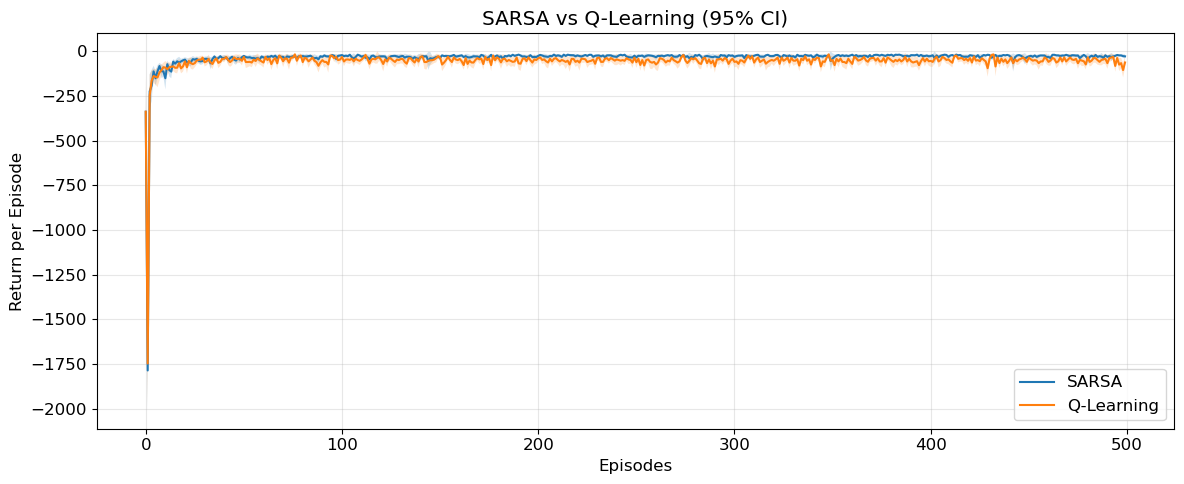

In [7]:
# -------------------------------
# Run experiment
# -------------------------------
SEEDS = 30
EPISODES = 500

params = {
    "lr": 0.5,
    "discount": 0.99,
    "eps_start": 0.1,
    "eps_min": 0.01,
    "eps_decay": 1.0,
}

print("Running SARSA...")
sarsa_results, sarsa_q = evaluate_across_seeds(
    method="sarsa",
    seeds=SEEDS,
    episodes=EPISODES,
    lr=params["lr"],
    discount=params["discount"],
    eps_start=params["eps_start"],
    eps_min=params["eps_min"],
    eps_decay=params["eps_decay"],
)

print("Running Q-Learning...")
q_results, qlearn_q = evaluate_across_seeds(
    method="q_learning",
    seeds=SEEDS,
    episodes=EPISODES,
    lr=params["lr"],
    discount=params["discount"],
    eps_start=params["eps_start"],
    eps_min=params["eps_min"],
    eps_decay=params["eps_decay"],
)

compare_algorithms(sarsa_results, q_results)

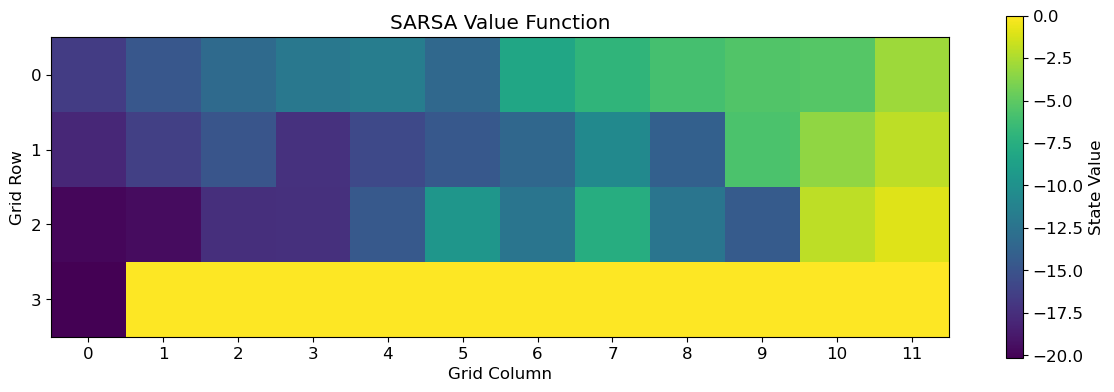

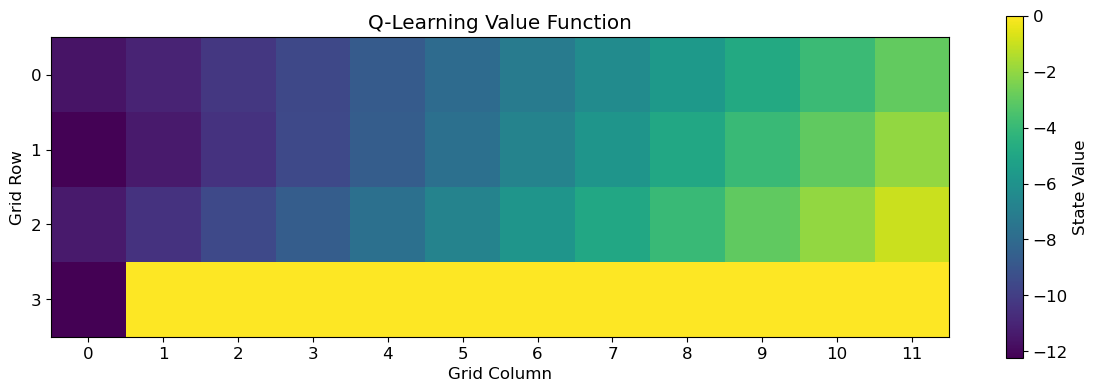

In [ ]:
def display_state_values(q_table, heading="State Value Visualization"):
    """
    Computes V(s) = max_a Q(s,a) and displays it as a 4x12 grid.
    """
    total_states, _ = q_table.shape
    
    if total_states != 48:
        raise ValueError("Expected 48 states for CliffWalking (4x12 grid).")

    # compute state values
    state_values = np.max(q_table, axis=1)
    grid_values = state_values.reshape(4, 12)

    fig, ax = plt.subplots(figsize=(12, 4))

    heatmap = ax.imshow(grid_values, interpolation="nearest", origin="upper")
    cbar = fig.colorbar(heatmap, ax=ax)
    cbar.set_label("State Value")

    ax.set_title(heading)
    ax.set_xlabel("Grid Column")
    ax.set_ylabel("Grid Row")

    ax.set_xticks(np.arange(12))
    ax.set_yticks(np.arange(4))

    plt.tight_layout()
    plt.show()



display_state_values(sarsa_q, heading="SARSA Value Function")
display_state_values(qlearn_q, heading="Q-Learning Value Function")

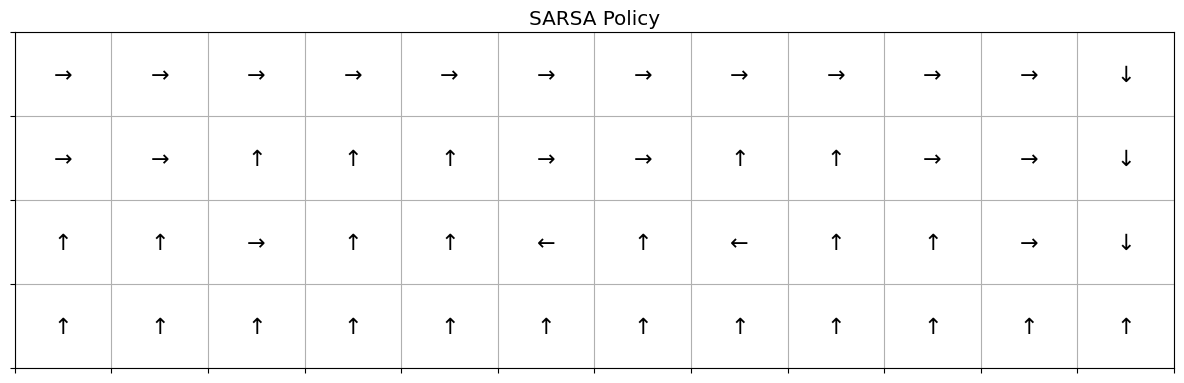

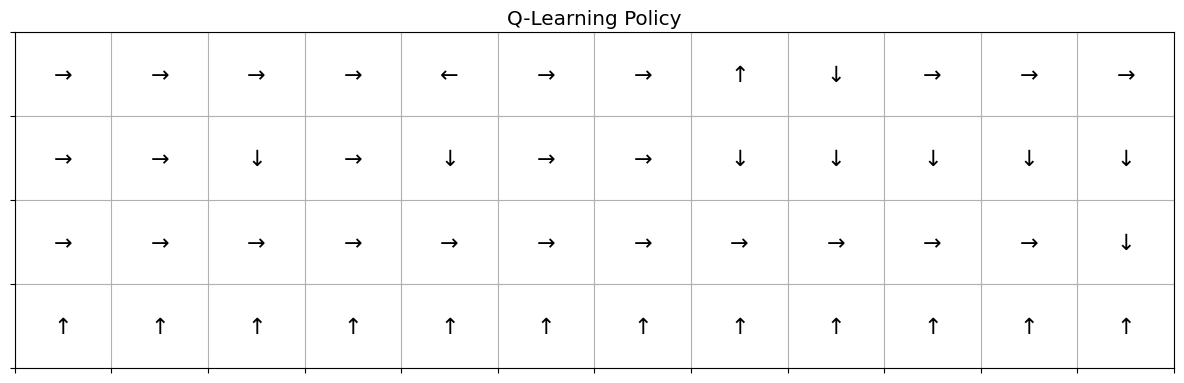

In [ ]:
def visualize_policy_grid(q_table, heading="Greedy Policy"):
    """
    Displays the policy derived from Q by selecting argmax action per state.
    Rendered as directional arrows on a 4x12 grid.
    """
    total_states, _ = q_table.shape

    if total_states != 48:
        raise ValueError("Expected a 4x12 grid (48 states).")

    # derive policy indices
    best_actions = np.argmax(q_table, axis=1)
    policy_grid = best_actions.reshape(4, 12)

    # arrow mapping
    arrows = ["↑", "→", "↓", "←"]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.set_title(heading)
    ax.set_xlim(0, 12)
    ax.set_ylim(4, 0)

    ax.set_xticks(np.arange(13))
    ax.set_yticks(np.arange(5))
    ax.grid(True)

    ax.set_xticklabels([])
    ax.set_yticklabels([])

    # place arrows
    for row in range(4):
        for col in range(12):
            action_idx = int(policy_grid[row, col])
            symbol = arrows[action_idx]

            ax.text(
                col + 0.5,
                row + 0.5,
                symbol,
                ha="center",
                va="center",
                fontsize=16
            )

    plt.tight_layout()
    plt.show()


visualize_policy_grid(sarsa_q, heading="SARSA Policy")
visualize_policy_grid(qlearn_q, heading="Q-Learning Policy")

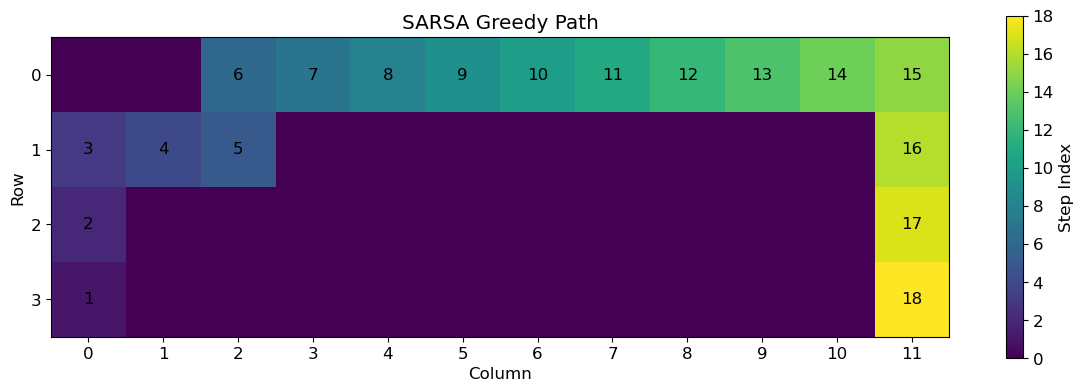

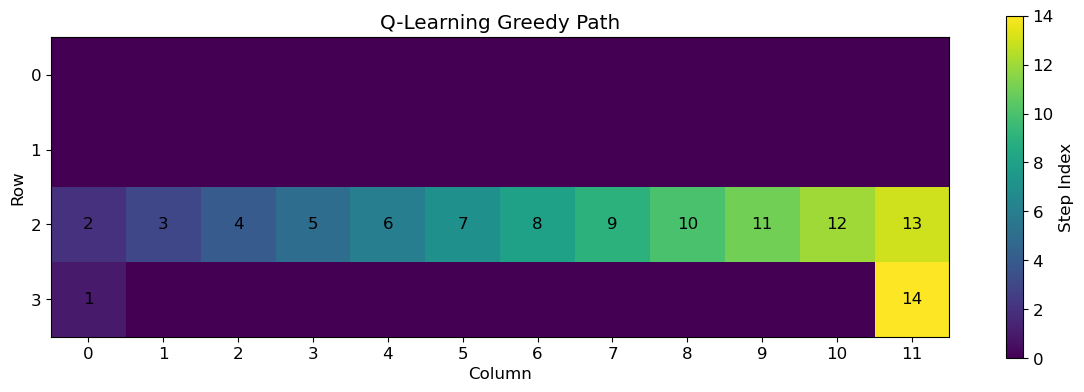

In [ ]:
def extract_greedy_path(q_table, step_limit=100):
    """
    Execute a deterministic (greedy) rollout using the learned Q-table.
    Returns a sequence of visited states.
    """
    env = gym.make("CliffWalking-v1")
    current_state, _ = env.reset()

    visited_states = [current_state]
    finished = False
    step_count = 0

    while not finished and step_count < step_limit:
        action = int(np.argmax(q_table[current_state]))

        next_state, reward, terminated, truncated, _ = env.step(action)
        finished = terminated or truncated

        visited_states.append(next_state)
        current_state = next_state
        step_count += 1

    env.close()
    return visited_states


def show_path_on_grid(state_sequence, heading="Agent Trajectory"):
    """
    Visualizes the order of visited states on a 4x12 grid.
    """
    layout = np.zeros((4, 12))

    for step_idx, state in enumerate(state_sequence, start=1):
        row, col = divmod(state, 12)
        layout[row, col] = step_idx

    fig, ax = plt.subplots(figsize=(12, 4))
    img = ax.imshow(layout, interpolation="nearest", origin="upper")

    cbar = fig.colorbar(img, ax=ax)
    cbar.set_label("Step Index")

    ax.set_title(heading)
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")

    ax.set_xticks(np.arange(12))
    ax.set_yticks(np.arange(4))

    # annotate steps
    for r in range(4):
        for c in range(12):
            if layout[r, c] > 0:
                ax.text(
                    c,
                    r,
                    int(layout[r, c]),
                    ha="center",
                    va="center"
                )

    plt.tight_layout()
    plt.show()


sarsa_path = extract_greedy_path(sarsa_q)
qlearn_path = extract_greedy_path(qlearn_q)

show_path_on_grid(sarsa_path, heading="SARSA Greedy Path")
show_path_on_grid(qlearn_path, heading="Q-Learning Greedy Path")

## Hyperparameter Experiments

In this section, we study how different parameter choices affect learning performance.

### Parameters Tested

- **Learning Rate (α):**  
  - 0.1  
  - 0.5  

- **Exploration Strategy (ε):**  
  - Fixed: ε = 0.1  
  - Decaying: εₜ = max(0.01, 0.99ᵗ)  

---

### How to Run

To perform these experiments, modify:
- `lr`
- `eps_init`
- `eps_decay_rate`

Then run the training again for both SARSA and Q-learning.

---

### Evaluation Criteria

We compare the algorithms based on:

- **Learning Speed:** how quickly rewards improve  
- **Stability:** how consistent the learning curves are  
- **Final Performance:** average reward over the last episodes  

---

In [11]:
def report_final_metrics(results_matrix, name, window=50):
    """
    Displays mean and variability of returns over the last 'window' episodes.
    """
    tail_segment = results_matrix[:, -window:]

    avg_score = np.mean(tail_segment)
    variability = np.std(tail_segment, ddof=1)

    print(f"{name} → Final {window}-episode performance: {avg_score:.2f} ± {variability:.2f}")

report_final_metrics(sarsa_results, "SARSA")
report_final_metrics(q_results, "Q-Learning")

SARSA → Final 50-episode performance: -27.80 ± 31.50
Q-Learning → Final 50-episode performance: -52.21 ± 72.25


## Evaluation and Analysis

In [ ]:
def compute_experiment_metrics(results, label, last_k=50):
    """
    Computes key evaluation metrics:
    - Final performance
    - Stability (std)
    - Learning speed (episodes to reach threshold)
    """
    # Final performance
    tail = results[:, -last_k:]
    final_mean = np.mean(tail)
    final_std = np.std(tail, ddof=1)

    # Learning speed 
    mean_curve = np.mean(results, axis=0)
    threshold = 0.9 * final_mean

    speed_idx = None
    for i, val in enumerate(mean_curve):
        if val >= threshold:
            speed_idx = i
            break

    if speed_idx is None:
        speed_idx = len(mean_curve)

    return {
        "name": label,
        "final_mean": final_mean,
        "final_std": final_std,
        "speed": speed_idx
    }

In [ ]:
def print_comparison_table(sarsa_results, q_results):
    sarsa_metrics = compute_experiment_metrics(sarsa_results, "SARSA")
    q_metrics = compute_experiment_metrics(q_results, "Q-Learning")

    print("\n=== Comparison Table ===\n")
    print(f"{'Algorithm':<12} | {'Final Return':<20} | {'Speed (ep)':<12}")
    print("-" * 55)

    for m in [sarsa_metrics, q_metrics]:
        print(
            f"{m['name']:<12} | "
            f"{m['final_mean']:.2f} ± {m['final_std']:.2f} | "
            f"{m['speed']:<12}"
        )

    return sarsa_metrics, q_metrics
sarsa_metrics, q_metrics = print_comparison_table(sarsa_results, q_results)


=== Comparison Table ===

Algorithm    | Final Return         | Speed (ep)  
-------------------------------------------------------
SARSA        | -27.80 ± 31.50 | 91          
Q-Learning   | -52.21 ± 72.25 | 29          


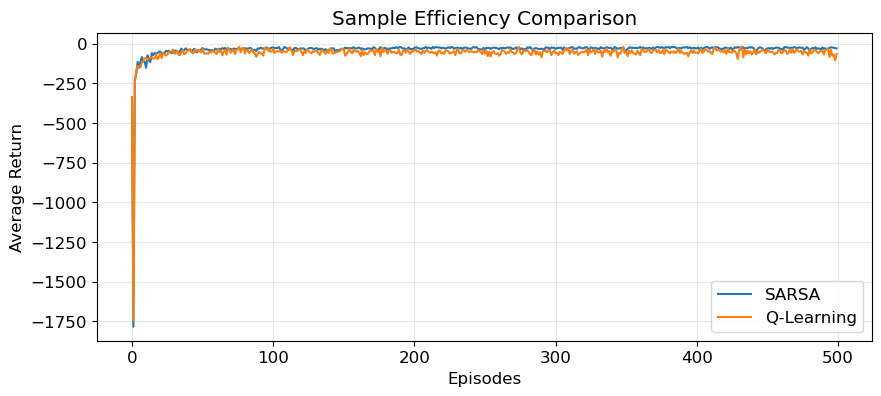

In [14]:
def plot_sample_efficiency(sarsa_results, q_results):
    sarsa_mean = np.mean(sarsa_results, axis=0)
    q_mean = np.mean(q_results, axis=0)

    plt.figure(figsize=(10, 4))
    plt.plot(sarsa_mean, label="SARSA")
    plt.plot(q_mean, label="Q-Learning")

    plt.xlabel("Episodes")
    plt.ylabel("Average Return")
    plt.title("Sample Efficiency Comparison")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


plot_sample_efficiency(sarsa_results, q_results)